# MAX-APC: Maximum-Weight Assignment Problem with Conflict Constraints

**Lagrangian Relaxation + Subgradient Optimization + Square-Swap Repair**

IE 492 — Boğaziçi University

---

### Pipeline
1. **Problem Generation** — Random instance with configurable parameters
2. **Presolve** — Remove redundant constraints, fix variables, bound tightening
3. **Lagrangian Relaxation** — Relax conflict constraints into objective via multipliers
4. **Hungarian Method** — Solve AP subproblem with modified costs → Upper Bound
5. **Square-Swap Repair** — Fix infeasible solutions → Lower Bound
6. **Subgradient Loop** — Iterate until UB ≈ LB or max iterations

In [1]:
import numpy as np
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import time
import math
from collections import defaultdict

np.random.seed(42)
print("Imports OK")

Imports OK


---
## 1. Problem Generation

Generate a random MAX-APC instance:
- $n \times n$ benefit matrix $C$ with entries in `[min_cost, max_cost]`
- Conflict set $E(\delta_c)$: pairs $\{(i,j),(k,\ell)\}$ where $i \neq k$ AND $j \neq \ell$
- Only edges in **different rows AND different columns** can conflict (same-row/column pairs are already forbidden by the assignment structure)
- `conflict_density` controls $|E(\delta_c)| / |P_{valid}|$ where $|P_{valid}| = \binom{n^2}{2} - 2 \cdot n \cdot \binom{n}{2}$

In [2]:
def generate_instance(n, min_cost=1, max_cost=100, conflict_density=0.02, seed=None):
    """
    Generate a random MAX-APC instance.
    
    Conflicts are only between edges in DIFFERENT rows AND DIFFERENT columns,
    because same-row or same-column edges can never coexist in an assignment.
    
    Parameters:
        n              : problem size (n agents, n tasks)
        min_cost       : minimum benefit value
        max_cost       : maximum benefit value
        conflict_density: fraction of valid conflict pairs (0.0 to 1.0)
        seed           : random seed for reproducibility
    
    Returns:
        C         : n×n benefit matrix
        conflicts : list of tuples [(i1,j1,i2,j2), ...]
    """
    if seed is not None:
        np.random.seed(seed)
    
    # Benefit matrix
    C = np.random.randint(min_cost, max_cost + 1, size=(n, n)).astype(float)
    
    # Valid conflict pairs: (i1,j1) vs (i2,j2) where i1≠i2 AND j1≠j2
    all_edges = [(i, j) for i in range(n) for j in range(n)]
    
    # Count valid pairs:
    # Total pairs = C(n^2, 2)
    # Same-row pairs = n * C(n, 2)
    # Same-col pairs = n * C(n, 2)
    # Valid = Total - same_row - same_col
    total_pairs = len(all_edges) * (len(all_edges) - 1) // 2
    same_row_pairs = n * (n * (n - 1) // 2)
    same_col_pairs = n * (n * (n - 1) // 2)
    valid_pairs = total_pairs - same_row_pairs - same_col_pairs
    
    num_conflicts = int(conflict_density * valid_pairs)
    
    conflicts = set()
    attempts = 0
    max_attempts = num_conflicts * 20
    
    while len(conflicts) < num_conflicts and attempts < max_attempts:
        idx1, idx2 = np.random.choice(len(all_edges), 2, replace=False)
        e1, e2 = all_edges[idx1], all_edges[idx2]
        
        # Skip if same row or same column
        if e1[0] == e2[0] or e1[1] == e2[1]:
            attempts += 1
            continue
        
        # Canonical ordering
        key = (min(e1, e2), max(e1, e2))
        if key not in conflicts:
            conflicts.add(key)
        attempts += 1
    
    conflict_list = [(e1[0], e1[1], e2[0], e2[1]) for e1, e2 in conflicts]
    
    print(f"Valid conflict pool: {valid_pairs} pairs")
    print(f"Generated conflicts: {len(conflict_list)} ({len(conflict_list)/valid_pairs*100:.1f}% of pool)")
    
    return C, conflict_list

In [3]:
# === CONFIGURABLE PARAMETERS ===
N = 15                   # Problem size
MIN_COST = 1             # Minimum benefit
MAX_COST = 100           # Maximum benefit
CONFLICT_DENSITY = 0.02  # Conflict density (fraction of valid pairs)
SEED = 42                # Random seed

C, conflicts = generate_instance(N, MIN_COST, MAX_COST, CONFLICT_DENSITY, SEED)

print(f"\nProblem size: {N}×{N}")
print(f"Benefit range: [{MIN_COST}, {MAX_COST}]")
print(f"Number of conflicts: {len(conflicts)}")
print(f"\nBenefit matrix C (first {N}x{N}):")
print(C[:N, :N].astype(int))

# === Verify with 3×3, density=1.0 ===
print(f"\n{'='*50}")
print("VERIFICATION: 3×3 with density=1.0")
_, test_conflicts = generate_instance(3, 1, 100, 1.0, seed=99)
print(f"  Expected max conflicts: 18")
print(f"  Got: {len(test_conflicts)}")
assert len(test_conflicts) == 18, f"ERROR: expected 18, got {len(test_conflicts)}"
for (i1, j1, i2, j2) in test_conflicts:
    assert i1 != i2, f"Same row conflict: ({i1},{j1})-({i2},{j2})"
    assert j1 != j2, f"Same col conflict: ({i1},{j1})-({i2},{j2})"
print("  All conflicts valid (different row AND different column)")
print("  PASSED")

Valid conflict pool: 22050 pairs
Generated conflicts: 441 (2.0% of pool)

Problem size: 15×15
Benefit range: [1, 100]
Number of conflicts: 441

Benefit matrix C (first 15x15):
[[ 52  93  15  72  61  21  83  87  75  75  88 100  24   3  22]
 [ 53   2  88  30  38   2  64  60  21  33  76  58  22  89  49]
 [ 91  59  42  92  60  80  15  62  62  47  62  51  55  64   3]
 [ 51   7  21  73  39  18   4  89  60  14   9  90  53   2  84]
 [ 92  60  71  44   8  47  35  78  81  36  50   4   2   6  54]
 [  4  54  93  63  18  90  44  34  74  62 100  14  95  48  15]
 [ 72  78  87  62  40  85  80  82  53  24  26  89  60  41  29]
 [ 15  45  65  89  71   9  88   1   8  88  63  11  81   8  35]
 [ 35  33   5  41  28   7  73  72  12  34  33  48  23  62  88]
 [ 37  99  44  86  91  35  65  99  47  78   3   1   5  90  14]
 [ 27   9  79  15  90  42  77  51  63  96  52  96   4  94  23]
 [ 15  43  29  36  13  32  71  59  86  28  66  42  45  62  57]
 [  6  28  28  44  84  30  62  75  92  89  62  97   1  27  62]
 [ 77

---
## 2. Mantıksal İndirgeme (Preprocessing)

Solver'a girmeden önce problemi küçültüyoruz — 3 aşamalı iteratif indirgeme:

### Kısım 1: Kesin 0 (Dead Cell Tarayıcısı)
Eğer $(i,j)$ seçilirse başka bir satır veya sütun **hiç atanamaz** hale geliyorsa → $(i,j)$ ölü hücre, matristen silinir.

- **Satır kontrolü**: Her diğer satır $r$ için: $r$'de en az bir canlı, $(i,j)$ ile çatışmayan, $j$'den farklı sütun var mı?
- **Sütun kontrolü**: Her diğer sütun $c$ için: $c$'de en az bir canlı, $(i,j)$ ile çatışmayan, $i$'den farklı satır var mı?

### Kısım 2: Kesin 1 (Forced Assignment) + Domino
- Satırda/sütunda **tek canlı hücre** kaldıysa → o atama **mecburi**
- Mecburi atama → aynı sütün/satırdaki herkesi sil (Domino)
- Mecburi atama → tüm düşmanları (conflict'li hücreleri) sil (Çatışma İnfazı)

Bu 3 kısım **değişiklik olmayana kadar** iteratif olarak tekrarlanır.

In [4]:
def presolve(C, conflicts, verbose=True):
    """
    Mantıksal İndirgeme (Preprocessing) for MAX-APC.
    
    3-phase iterative reduction:
      1. Dead Cell Scanner  — if selecting (i,j) makes some row/col impossible
      2. Forced Assignment  — if row/col has single alive cell → forced
      3. Domino + Conflict  — forced cell kills same-row/col + enemies
    
    Returns: reduced_conflicts, fixed_zeros, neighbors
    """
    n = C.shape[0]
    original_num_conflicts = len(conflicts)
    
    # --- Step 0: Dedup and remove invalid conflicts (same-row/col) ---
    clean_conflicts = []
    seen = set()
    removed_invalid = 0
    for (i1, j1, i2, j2) in conflicts:
        if (i1, j1) == (i2, j2):
            continue
        if i1 == i2 or j1 == j2:
            removed_invalid += 1
            continue
        e1, e2 = (i1, j1), (i2, j2)
        if e1 > e2:
            e1, e2 = e2, e1
        key = (e1[0], e1[1], e2[0], e2[1])
        if key not in seen:
            seen.add(key)
            clean_conflicts.append(key)
    
    # Build conflict neighborhood map: (i,j) -> set of (k,l)
    conflict_map = defaultdict(set)
    for (i1, j1, i2, j2) in clean_conflicts:
        conflict_map[(i1, j1)].add((i2, j2))
        conflict_map[(i2, j2)].add((i1, j1))
    
    # Track alive cells (not yet eliminated)
    alive = np.ones((n, n), dtype=bool)
    
    changed = True
    iteration = 1
    total_eliminated = 0
    print_limit = 20
    print_count = 0
    
    if verbose:
        print("\n[Aşama 0] Mantıksal İndirgeme (Preprocessing) Başladı...")
        if removed_invalid > 0:
            print(f"  Geçersiz conflict silindi: {removed_invalid} (aynı satır/sütun)")
        print(f"  Temiz conflict sayısı: {len(clean_conflicts)}")
    
    while changed:
        changed = False
        
        # ─────────────────────────────────────────────────────
        # KISIM 1: "KESİN 0" (DEAD CELL) TARAYICISI
        # ─────────────────────────────────────────────────────
        for i in range(n):
            for j in range(n):
                if not alive[i, j]:
                    continue
                
                is_dead = False
                
                # SATIR KONTROLÜ: her diğer satır r için,
                # r'de en az bir canlı, (i,j) ile çatışmayan, j'den farklı sütun var mı?
                for r in range(n):
                    if r == i:
                        continue
                    can_assign = False
                    for c in range(n):
                        if c == j:
                            continue
                        if alive[r, c] and (r, c) not in conflict_map[(i, j)]:
                            can_assign = True
                            break
                    if not can_assign:
                        is_dead = True
                        break
                
                # SÜTUN KONTROLÜ: her diğer sütun c için,
                # c'de en az bir canlı, (i,j) ile çatışmayan, i'den farklı satır var mı?
                if not is_dead:
                    for c in range(n):
                        if c == j:
                            continue
                        can_assign = False
                        for r in range(n):
                            if r == i:
                                continue
                            if alive[r, c] and (r, c) not in conflict_map[(i, j)]:
                                can_assign = True
                                break
                        if not can_assign:
                            is_dead = True
                            break
                
                if is_dead:
                    alive[i, j] = False
                    changed = True
                    total_eliminated += 1
                    if verbose and print_count < print_limit:
                        print(f"  -> İterasyon {iteration} [Kesin 0]: Hücre ({i}, {j}) imkansız, silindi.")
                        print_count += 1
        
        # ─────────────────────────────────────────────────────
        # KISIM 2: "KESİN 1" (FORCED ASSIGNMENT) + DOMİNO
        # ─────────────────────────────────────────────────────
        
        # A) Satırlar için "Tek Çare" Kontrolü
        for i in range(n):
            alive_cols = [j for j in range(n) if alive[i, j]]
            if len(alive_cols) == 1:
                forced_j = alive_cols[0]
                
                # Sütundaki diğer herkesi sil
                for r in range(n):
                    if r != i and alive[r, forced_j]:
                        alive[r, forced_j] = False
                        changed = True
                        total_eliminated += 1
                        if verbose and print_count < print_limit:
                            print(f"  -> Domino [Satır Mecburluğu]: ({i},{forced_j}) kesin → ({r},{forced_j}) silindi.")
                            print_count += 1
                
                # Düşmanları sil
                for (conf_r, conf_c) in conflict_map[(i, forced_j)]:
                    if alive[conf_r, conf_c]:
                        alive[conf_r, conf_c] = False
                        changed = True
                        total_eliminated += 1
                        if verbose and print_count < print_limit:
                            print(f"  -> Çatışma İnfazı: ({i},{forced_j}) kesin → düşmanı ({conf_r},{conf_c}) silindi.")
                            print_count += 1
        
        # B) Sütunlar için "Tek Çare" Kontrolü
        for j in range(n):
            alive_rows = [i for i in range(n) if alive[i, j]]
            if len(alive_rows) == 1:
                forced_i = alive_rows[0]
                
                # Satırdaki diğer herkesi sil
                for c in range(n):
                    if c != j and alive[forced_i, c]:
                        alive[forced_i, c] = False
                        changed = True
                        total_eliminated += 1
                        if verbose and print_count < print_limit:
                            print(f"  -> Domino [Sütun Mecburluğu]: ({forced_i},{j}) kesin → ({forced_i},{c}) silindi.")
                            print_count += 1
                
                # Düşmanları sil
                for (conf_r, conf_c) in conflict_map[(forced_i, j)]:
                    if alive[conf_r, conf_c]:
                        alive[conf_r, conf_c] = False
                        changed = True
                        total_eliminated += 1
                        if verbose and print_count < print_limit:
                            print(f"  -> Çatışma İnfazı: ({forced_i},{j}) kesin → düşmanı ({conf_r},{conf_c}) silindi.")
                            print_count += 1
        
        iteration += 1
    
    # --- Collect results ---
    fixed_zeros = set()
    for i in range(n):
        for j in range(n):
            if not alive[i, j]:
                fixed_zeros.add((i, j))
    
    # Remove conflicts involving eliminated edges
    reduced_conflicts = []
    for (i1, j1, i2, j2) in clean_conflicts:
        if alive[i1, j1] and alive[i2, j2]:
            reduced_conflicts.append((i1, j1, i2, j2))
    
    # Rebuild neighbors
    neighbors_reduced = defaultdict(set)
    for (i1, j1, i2, j2) in reduced_conflicts:
        neighbors_reduced[(i1, j1)].add((i2, j2))
        neighbors_reduced[(i2, j2)].add((i1, j1))
    
    if verbose:
        if total_eliminated > print_limit:
            print(f"  -> ... (ve {total_eliminated - print_limit} adet daha indirgeme logu gizlendi)")
        
        alive_count = int(alive.sum())
        print(f"\n[Aşama 0] Tamamlandı. {iteration-1} iterasyonda {total_eliminated} hücre elendi.")
        print(f"=== PRESOLVE RESULTS ===")
        print(f"  Original conflicts:  {original_num_conflicts}")
        print(f"  After dedup:         {len(clean_conflicts)}")
        print(f"  Eliminated cells:    {total_eliminated} / {n*n}")
        print(f"  Alive cells:         {alive_count} / {n*n}")
        print(f"  Reduced conflicts:   {len(reduced_conflicts)}")
        edges_in_conflicts = set()
        for (i1, j1, i2, j2) in reduced_conflicts:
            edges_in_conflicts.add((i1, j1))
            edges_in_conflicts.add((i2, j2))
        print(f"  Edges in conflicts:  {len(edges_in_conflicts)} / {alive_count}")
        max_degree = max((len(v) for v in neighbors_reduced.values()), default=0)
        print(f"  Max conflict degree: {max_degree}")
    
    return reduced_conflicts, fixed_zeros, neighbors_reduced

In [5]:
conflicts, fixed_zeros, neighbors = presolve(C, conflicts)


[Aşama 0] Mantıksal İndirgeme (Preprocessing) Başladı...
  Temiz conflict sayısı: 441

[Aşama 0] Tamamlandı. 1 iterasyonda 0 hücre elendi.
=== PRESOLVE RESULTS ===
  Original conflicts:  441
  After dedup:         441
  Eliminated cells:    0 / 225
  Alive cells:         225 / 225
  Reduced conflicts:   441
  Edges in conflicts:  222 / 225
  Max conflict degree: 11


---
## 3. Core Solver Components

### 3.1 Hungarian Method (Lagrangian Subproblem)
Solve $SP(\boldsymbol{\lambda})$: standard AP with modified costs $\tilde{c}_{ij}(\boldsymbol{\lambda})$.

$$\tilde{c}_{ij}(\boldsymbol{\lambda}) = c_{ij} - \sum_{(k,\ell) \in N_{\delta_c}(i,j)} \lambda_{ij,k\ell}$$

$$L(\boldsymbol{\lambda}) = \max_x \sum \tilde{c}_{ij} x_{ij} + \sum \lambda_{ij,k\ell}$$

Since `scipy.optimize.linear_sum_assignment` **minimizes**, we negate the modified costs.

In [6]:
def solve_lagrangian_subproblem(C, lam, conflicts, neighbors, fixed_zeros):
    """
    Solve SP(lambda): AP with modified costs using Hungarian method.
    
    Returns:
        L_lambda : Lagrangian bound L(lambda) = AP_obj + sum(lambda)
        x        : n-length array, x[i] = column assigned to row i
        ap_obj   : raw AP objective (sum of modified costs)
    """
    n = C.shape[0]
    
    # Build conflict key -> lambda mapping
    lam_by_edge = defaultdict(float)  # (i,j) -> sum of lambda for all conflicts involving (i,j)
    for (i1, j1, i2, j2), val in lam.items():
        lam_by_edge[(i1, j1)] += val
        lam_by_edge[(i2, j2)] += val
    
    # Modified cost: c_tilde[i,j] = c[i,j] - sum of lambda for conflicts of (i,j)
    c_tilde = C.copy()
    for (i, j), penalty in lam_by_edge.items():
        c_tilde[i, j] -= penalty
    
    # Force fixed-zero edges to have very low benefit (won't be chosen)
    for (i, j) in fixed_zeros:
        c_tilde[i, j] = -1e9
    
    # Solve AP: scipy minimizes, we want to maximize -> negate
    row_ind, col_ind = linear_sum_assignment(-c_tilde)
    
    # Assignment: x[i] = j
    x = np.full(n, -1, dtype=int)
    x[row_ind] = col_ind
    
    # AP objective with modified costs
    ap_obj = sum(c_tilde[i, x[i]] for i in range(n))
    
    # L(lambda) = AP_obj + sum(all lambda)
    lam_sum = sum(lam.values())
    L_lambda = ap_obj + lam_sum
    
    return L_lambda, x, ap_obj

### 3.2 Feasibility Check & Conflict Detection

In [7]:
def find_violations(x, conflicts):
    """
    Find all violated conflict constraints.
    x[i] = column assigned to row i.
    Returns list of violated conflict tuples.
    """
    violations = []
    assignment_set = set((i, x[i]) for i in range(len(x)))
    for (i1, j1, i2, j2) in conflicts:
        if (i1, j1) in assignment_set and (i2, j2) in assignment_set:
            violations.append((i1, j1, i2, j2))
    return violations


def is_feasible(x, conflicts):
    """Check if assignment x has zero conflict violations."""
    return len(find_violations(x, conflicts)) == 0


def objective_value(x, C):
    """Compute sum of benefits for assignment x."""
    return sum(C[i, x[i]] for i in range(len(x)))

### 3.3 Square-Swap Repair Mechanism

When the Hungarian solution violates conflicts, we repair it:

1. **Identify** all active conflicts in current solution
2. **For each conflict** $\{(i,j),(k,l)\}$: pick the lower-benefit edge to move
3. **Square Swap**: find row $m$ where swapping $(k,l) \leftrightarrow (m,v)$ gives minimum benefit loss and creates no new conflicts
4. **Repeat** until no conflicts remain

In [8]:
def repair_solution(x, C, conflicts, neighbors):
    """
    Square-Swap Repair: resolve all conflicts while preserving assignment structure.
    
    x[i] = column assigned to row i (modified in-place copy).
    Returns repaired assignment or None if repair fails.
    """
    n = len(x)
    x_hat = x.copy()
    max_repair_rounds = n * n  # safety limit
    
    for round_num in range(max_repair_rounds):
        # Step 1: Find all active conflicts
        violations = find_violations(x_hat, conflicts)
        if not violations:
            return x_hat  # Feasible!
        
        # Step 2: Pick conflict with lowest combined benefit (cheapest to break)
        violations.sort(key=lambda v: C[v[0], v[1]] + C[v[2], v[3]])
        (i1, j1, i2, j2) = violations[0]
        
        # Decide which edge to move: the one with LOWER benefit
        if C[i1, j1] <= C[i2, j2]:
            k, l = i1, j1  # edge to move
            i_keep, j_keep = i2, j2
        else:
            k, l = i2, j2
            i_keep, j_keep = i1, j1
        
        # Step 3: Find best square swap for edge (k, l)
        best_m = -1
        best_delta = -float('inf')
        best_v = -1
        
        for m in range(n):
            if m == k or m == i_keep:
                continue
            
            v = x_hat[m]  # current column assigned to row m
            if v == l:
                continue  # same column, no swap possible
            
            # Proposed swap: (k,l) and (m,v) become (k,v) and (m,l)
            delta = (C[k, v] + C[m, l]) - (C[k, l] + C[m, v])
            
            # Check feasibility: would (k,v) or (m,l) create new conflicts?
            new_assignment = set((r, x_hat[r]) for r in range(n))
            new_assignment.discard((k, l))
            new_assignment.discard((m, v))
            new_assignment.add((k, v))
            new_assignment.add((m, l))
            
            # Quick conflict check for the two new edges only
            creates_new = False
            for (kk, ll) in neighbors.get((k, v), set()):
                if (kk, ll) in new_assignment:
                    creates_new = True
                    break
            if not creates_new:
                for (kk, ll) in neighbors.get((m, l), set()):
                    if (kk, ll) in new_assignment:
                        creates_new = True
                        break
            
            if not creates_new and delta > best_delta:
                best_delta = delta
                best_m = m
                best_v = v
        
        if best_m != -1:
            # Execute swap
            x_hat[k] = best_v
            x_hat[best_m] = l
        else:
            # No clean swap found — force: pick swap with fewest new conflicts
            best_m_forced = -1
            min_new_conflicts = float('inf')
            best_delta_forced = -float('inf')
            
            for m in range(n):
                if m == k or m == i_keep:
                    continue
                v = x_hat[m]
                if v == l:
                    continue
                
                # Count new conflicts this swap would create
                new_assignment = set((r, x_hat[r]) for r in range(n))
                new_assignment.discard((k, l))
                new_assignment.discard((m, v))
                new_assignment.add((k, v))
                new_assignment.add((m, l))
                
                nc = 0
                for (kk, ll) in neighbors.get((k, v), set()):
                    if (kk, ll) in new_assignment:
                        nc += 1
                for (kk, ll) in neighbors.get((m, l), set()):
                    if (kk, ll) in new_assignment:
                        nc += 1
                
                delta = (C[k, v] + C[m, l]) - (C[k, l] + C[m, v])
                
                if nc < min_new_conflicts or (nc == min_new_conflicts and delta > best_delta_forced):
                    min_new_conflicts = nc
                    best_delta_forced = delta
                    best_m_forced = m
            
            if best_m_forced != -1:
                v = x_hat[best_m_forced]
                x_hat[k] = v
                x_hat[best_m_forced] = l
            else:
                # Last resort: cannot repair this conflict
                break
    
    # Final check
    if is_feasible(x_hat, conflicts):
        return x_hat
    return None  # Repair failed

### 3.4 Greedy Initial Lower Bound

Sort edges by benefit descending, greedily build a conflict-free assignment.

In [9]:
def greedy_initial_solution(C, conflicts, neighbors):
    """
    Greedy heuristic: assign highest-benefit edges first, skip conflicts.
    Returns assignment x and its objective value.
    """
    n = C.shape[0]
    
    # Sort all edges by benefit descending
    edges = [(C[i, j], i, j) for i in range(n) for j in range(n)]
    edges.sort(reverse=True)
    
    x = np.full(n, -1, dtype=int)
    used_cols = set()
    assigned_edges = set()
    
    for (val, i, j) in edges:
        if x[i] != -1 or j in used_cols:
            continue
        
        # Check conflicts
        conflict_found = False
        for (k, l) in neighbors.get((i, j), set()):
            if (k, l) in assigned_edges:
                conflict_found = True
                break
        
        if not conflict_found:
            x[i] = j
            used_cols.add(j)
            assigned_edges.add((i, j))
    
    # Fill unassigned rows with remaining columns
    remaining_cols = [j for j in range(n) if j not in used_cols]
    unassigned_rows = [i for i in range(n) if x[i] == -1]
    
    for i, j in zip(unassigned_rows, remaining_cols):
        # Pick best remaining column that doesn't create conflict
        best_j = j
        best_val = C[i, j]
        for jj in remaining_cols:
            if jj in used_cols:
                continue
            ok = True
            for (k, l) in neighbors.get((i, jj), set()):
                if (k, l) in assigned_edges:
                    ok = False
                    break
            if ok and C[i, jj] > best_val:
                best_val = C[i, jj]
                best_j = jj
        x[i] = best_j
        used_cols.add(best_j)
        assigned_edges.add((i, best_j))
        remaining_cols = [c for c in remaining_cols if c not in used_cols]
    
    obj = objective_value(x, C)
    feasible = is_feasible(x, conflicts)
    return x, obj, feasible

### 3.5 — 3D Apartment Pathfinding Algorithm (Uzaysal Yol Bulma)

Problemi 2D matris yerine, **çatışmaların derinlik (Z) oluşturduğu bir uzaysal graf** olarak ele alır.

**Apartman Modeli:**
- **Z₀ (Çatı Katı):** Tüm hücreler mevcut. En yüksek faydalı hücreyi seç.
- **Z₁:** İlk atamadan sonra satır/sütün/düşmanlar silinir → arama uzayı daralır.
- **Z₂, Z₃, ...:** Her katta alan daralır (n → n-1 → ... → 1).
- **Zemin Kat:** Son atama tamamlanır.

**Her katta:**
1. Canlı hücreleri `fayda × (1 - çatışma_oranı)` skoruyla sırala
2. En yüksek skorlu hücreyi seç → satırını, sütununu, düşmanlarını sil
3. Çıkmaz (dead-end) olursa **bir üst kata backtrack** et, ikinci en iyiyi dene

**Beam Width = N**: Her katta **tüm** alternatifler denenir (tam DFS, skor sıralı backtracking). Ne indirgiyorsak çözdük — arama uzayı zaten her katta daralır.

$$\text{score}(i,j) = C_{ij} \times \left(1 - \frac{|\text{conflict\_neighbors}(i,j) \cap \text{alive}|}{|\text{alive}|}\right)$$

In [10]:
def apartment_pathfinding(C, conflicts, neighbors, fixed_zeros=set(),
                          beam_width=None, verbose=True):
    """
    3D Apartment Pathfinding Algorithm for MAX-APC.
    
    Top-down descent through Z-layers with backtracking.
    Each layer = one assignment decision, search space narrows per layer.
    
    Parameters:
        beam_width: max candidates to try per layer (default=N, tüm alternatifler)
    
    Returns:
        x_best, obj_best, feasible, route_history
        route_history: list of dicts per layer for 3D visualization
    """
    n = C.shape[0]
    if beam_width is None:
        beam_width = n  # Varsayılan: N — tüm adayları dene
    t_start = time.time()
    
    # Track best solution found across all attempts
    best_x = None
    best_obj = -1
    route_history = []  # For visualization: snapshots per layer
    
    def compute_score(i, j, avail_rows, avail_cols, assigned_edges):
        """Score = benefit * (1 - conflict_ratio). Higher = better."""
        # Count how many alive cells conflict with (i,j)
        alive_conflicts = 0
        alive_total = 0
        for r in avail_rows:
            for c in avail_cols:
                if (r, c) in fixed_zeros:
                    continue
                alive_total += 1
                if (r, c) in neighbors.get((i, j), set()):
                    alive_conflicts += 1
        
        ratio = alive_conflicts / max(alive_total, 1)
        return C[i, j] * (1 - ratio)
    
    def descend(depth, avail_rows, avail_cols, assigned_edges, x, route):
        """Recursive descent with backtracking."""
        nonlocal best_x, best_obj, route_history
        
        if depth == n:
            # All rows assigned — check feasibility
            obj = objective_value(x, C)
            feas = is_feasible(x, conflicts)
            if feas and obj > best_obj:
                best_obj = obj
                best_x = x.copy()
                route_history = [r.copy() for r in route]
            return feas
        
        # Build candidates for this layer
        candidates = []
        for i in sorted(avail_rows):
            for j in sorted(avail_cols):
                if (i, j) in fixed_zeros:
                    continue
                # Check: does (i,j) conflict with any already-assigned edge?
                conflict_with_assigned = False
                for (k, l) in neighbors.get((i, j), set()):
                    if (k, l) in assigned_edges:
                        conflict_with_assigned = True
                        break
                if not conflict_with_assigned:
                    score = compute_score(i, j, avail_rows, avail_cols, assigned_edges)
                    candidates.append((score, C[i, j], i, j))
        
        if not candidates:
            return False  # Dead end — backtrack
        
        # Sort: highest score first
        candidates.sort(reverse=True)
        
        # Snapshot for visualization
        layer_snapshot = {
            'depth': depth,
            'candidates': [(i, j, C[i, j], sc) for (sc, b, i, j) in candidates],
            'avail_rows': sorted(avail_rows),
            'avail_cols': sorted(avail_cols),
            'eliminated': [(i, j) for i in range(n) for j in range(n)
                          if (i not in avail_rows or j not in avail_cols 
                              or (i, j) in fixed_zeros)
                          and (i, j) not in assigned_edges],
            'assigned_so_far': list(assigned_edges),
            'selected': None,  # Will be set below
        }
        
        # Try top beam_width candidates (beam_width=N → tüm adaylar)
        for rank, (score, benefit, i, j) in enumerate(candidates[:beam_width]):
            # Select this cell
            x[i] = j
            new_assigned = assigned_edges | {(i, j)}
            new_rows = avail_rows - {i}
            new_cols = avail_cols - {j}
            
            # Record selection
            layer_snapshot['selected'] = (i, j, benefit, score)
            route.append(layer_snapshot.copy())
            
            if verbose and depth < 3:
                pad = "  " * depth
                remaining = len(new_rows)
                print(f"{pad}Z{depth}: ({i},{j}) benefit={benefit:.0f} "
                      f"score={score:.1f} [{remaining} rows left, "
                      f"{len(candidates)} candidates]")
            
            # Descend to next layer
            success = descend(depth + 1, new_rows, new_cols, new_assigned, x, route)
            
            if success:
                return True
            
            # Backtrack
            x[i] = -1
            route.pop()
            
            if verbose and depth < 2:
                pad = "  " * depth
                print(f"{pad}  BACKTRACK from Z{depth}: ({i},{j}) failed, "
                      f"trying rank {rank+2}...")
        
        return False  # All candidates at this level failed
    
    if verbose:
        print(f"\n[Apartment Pathfinding] n={n}, beam_width={beam_width}")
        print(f"{'='*55}")
    
    x = np.full(n, -1, dtype=int)
    success = descend(0, set(range(n)), set(range(n)), set(), x, [])
    
    elapsed = time.time() - t_start
    
    if verbose:
        print(f"{'='*55}")
        if best_x is not None:
            print(f"  Result: objective={best_obj:.0f}, feasible=True")
        else:
            print(f"  Result: No feasible solution found")
        print(f"  Time: {elapsed:.3f}s")
    
    feasible = best_x is not None
    return best_x, best_obj if feasible else 0, feasible, route_history

In [11]:
def visualize_apartment_3d(C, route_history, conflicts, neighbors, n):
    """
    3D visualization of the Apartment Pathfinding descent.
    
    X = Column (Task), Y = Row (Agent), Z = Layer (Depth, inverted so Z0 = top)
    """
    from mpl_toolkits.mplot3d import Axes3D
    from mpl_toolkits.mplot3d.art3d import Poly3DCollection
    
    fig = plt.figure(figsize=(16, 12))
    ax = fig.add_subplot(111, projection='3d')
    
    max_depth = len(route_history)
    
    # Color scheme
    color_selected = '#10B981'   # Emerald green (selected cells)
    color_candidate = '#3B82F6'  # Blue (available candidates)
    color_dead = '#EF4444'       # Red (eliminated)
    color_route = '#F59E0B'      # Amber (route line)
    
    # Draw each layer
    route_points = []
    
    for layer in route_history:
        depth = layer['depth']
        z = max_depth - depth  # Invert: Z0 is at top
        
        selected = layer['selected']  # (i, j, benefit, score)
        candidates = layer['candidates']  # [(i, j, benefit, score), ...]
        eliminated = layer['eliminated']
        
        # Draw semi-transparent floor plane
        floor_x = [-0.5, n - 0.5, n - 0.5, -0.5]
        floor_y = [-0.5, -0.5, n - 0.5, n - 0.5]
        floor_z = [z, z, z, z]
        verts = [list(zip(floor_x, floor_y, floor_z))]
        plane = Poly3DCollection(verts, alpha=0.05, facecolor='gray', edgecolor='gray', linewidth=0.5)
        ax.add_collection3d(plane)
        
        # Layer label
        ax.text(-1.2, n / 2, z, f'Z{depth}', fontsize=10, fontweight='bold',
                color='#374151', ha='center')
        
        # Draw eliminated cells (small red dots)
        for (i, j) in eliminated[:50]:  # Limit for performance
            ax.scatter(j, i, z, c=color_dead, s=8, alpha=0.15, marker='x')
        
        # Draw candidates (blue dots)
        for (ci, cj, cb, cs) in candidates:
            if selected and (ci, cj) == (selected[0], selected[1]):
                continue  # Will draw selected separately
            ax.scatter(cj, ci, z, c=color_candidate, s=25, alpha=0.4, marker='o')
        
        # Draw selected cell (large green star)
        if selected:
            si, sj, sb, ss = selected
            ax.scatter(sj, si, z, c=color_selected, s=200, alpha=1.0, 
                      marker='*', edgecolors='darkgreen', linewidths=0.5,
                      zorder=10)
            ax.text(sj + 0.3, si, z + 0.15, f'({si},{sj})\nb={sb:.0f}',
                   fontsize=7, color=color_selected, fontweight='bold')
            route_points.append((sj, si, z))
    
    # Draw route line connecting selected cells
    if len(route_points) >= 2:
        rx = [p[0] for p in route_points]
        ry = [p[1] for p in route_points]
        rz = [p[2] for p in route_points]
        ax.plot(rx, ry, rz, color=color_route, linewidth=3, alpha=0.8,
               linestyle='-', marker='o', markersize=6)
    
    # Draw conflict edges (thin red lines between conflicting selected cells)
    assigned = set()
    for layer in route_history:
        if layer['selected']:
            assigned.add((layer['selected'][0], layer['selected'][1]))
    
    for (i1, j1, i2, j2) in conflicts:
        if (i1, j1) in assigned and (i2, j2) in assigned:
            # Find their Z layers
            z1 = z2 = None
            for layer in route_history:
                if layer['selected'] and (layer['selected'][0], layer['selected'][1]) == (i1, j1):
                    z1 = max_depth - layer['depth']
                if layer['selected'] and (layer['selected'][0], layer['selected'][1]) == (i2, j2):
                    z2 = max_depth - layer['depth']
            if z1 is not None and z2 is not None:
                ax.plot([j1, j2], [i1, i2], [z1, z2], 
                       color='red', linewidth=2, alpha=0.6, linestyle='--')
    
    # Formatting
    ax.set_xlabel('Column (Task)', fontsize=11, labelpad=10)
    ax.set_ylabel('Row (Agent)', fontsize=11, labelpad=10)
    ax.set_zlabel('Layer (Depth)', fontsize=11, labelpad=10)
    ax.set_title('3D Apartment Pathfinding — Uzaysal Rota\n'
                 '(Top = Z0 Roof, Bottom = Ground Floor)',
                 fontsize=13, fontweight='bold', pad=20)
    
    # Set axis limits
    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(-0.5, n - 0.5)
    ax.set_zlim(0, max_depth + 0.5)
    
    # View angle
    ax.view_init(elev=25, azim=45)
    
    # Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='*', color='w', markerfacecolor=color_selected,
               markersize=15, label='Selected (Route)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=color_candidate,
               markersize=8, label='Available Candidates'),
        Line2D([0], [0], marker='x', color='w', markerfacecolor=color_dead,
               markersize=8, label='Eliminated'),
        Line2D([0], [0], color=color_route, linewidth=3, label='Descent Route'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('apartment_3d.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 4. Subgradient Optimization Loop

Full Algorithm 1 from the derivation:

$$t_k = \frac{\alpha_k (L(\boldsymbol{\lambda}^k) - LB_{best})}{\|\boldsymbol{g}^k\|^2}$$

$$\lambda^{k+1}_{ij,k\ell} = \max\{0,\; \lambda^k_{ij,k\ell} + t_k \cdot g^k_{ij,k\ell}\}$$

where $g^k_{ij,k\ell} = x^k_{ij} + x^k_{k\ell} - 1$.

In [12]:
def subgradient_solve(C, conflicts, neighbors, fixed_zeros,
                      max_iter=500, alpha_init=2.0, eps=1e-4, verbose=True):
    """
    Full Subgradient Optimization for MAX-APC.
    
    Returns:
        results dict with UB_best, LB_best, gap, best_x, history
    """
    n = C.shape[0]
    t_start = time.time()
    
    # --- Initialize ---
    # Lambda: one multiplier per conflict pair
    lam = {(i1, j1, i2, j2): 0.0 for (i1, j1, i2, j2) in conflicts}
    alpha = alpha_init
    
    # Greedy initial LB
    x_greedy, lb_greedy, greedy_feasible = greedy_initial_solution(C, conflicts, neighbors)
    LB_best = lb_greedy if greedy_feasible else 0.0
    x_best = x_greedy.copy() if greedy_feasible else None
    UB_best = float('inf')
    
    if verbose:
        print(f"Greedy LB: {lb_greedy:.0f} (feasible={greedy_feasible})")
    
    # History for plotting
    history = {'UB': [], 'LB': [], 'gap': [], 'violations': []}
    no_improve_count = 0
    
    for k in range(max_iter):
        # --- Step 1-2: Solve Lagrangian subproblem ---
        L_lam, x_k, ap_obj = solve_lagrangian_subproblem(C, lam, conflicts, neighbors, fixed_zeros)
        
        # --- Step 3: Update Upper Bound ---
        UB_best = min(UB_best, L_lam)
        
        # --- Step 4: Feasibility repair ---
        violations = find_violations(x_k, conflicts)
        num_violations = len(violations)
        
        if num_violations == 0:
            # Already feasible!
            x_hat = x_k
        else:
            # Repair
            x_hat = repair_solution(x_k, C, conflicts, neighbors)
        
        # Update Lower Bound
        if x_hat is not None and is_feasible(x_hat, conflicts):
            lb_current = objective_value(x_hat, C)
            if lb_current > LB_best:
                LB_best = lb_current
                x_best = x_hat.copy()
                no_improve_count = 0
            else:
                no_improve_count += 1
        else:
            no_improve_count += 1
        
        # --- Step 5: Termination check ---
        gap = (UB_best - LB_best) / max(abs(UB_best), 1e-10) * 100 if UB_best != float('inf') else 100.0
        
        history['UB'].append(UB_best)
        history['LB'].append(LB_best)
        history['gap'].append(gap)
        history['violations'].append(num_violations)
        
        if verbose and (k % 50 == 0 or k < 5 or gap < eps):
            print(f"  k={k:4d}  UB={UB_best:10.2f}  LB={LB_best:10.2f}  "
                  f"Gap={gap:6.2f}%  Viol={num_violations}  α={alpha:.4f}")
        
        if gap < eps:
            if verbose:
                print(f"\n*** OPTIMAL (gap < {eps}%) at iteration {k} ***")
            break
        
        # --- Step 6: Subgradient ---
        g = {}
        for (i1, j1, i2, j2) in conflicts:
            g_val = (1 if x_k[i1] == j1 else 0) + (1 if x_k[i2] == j2 else 0) - 1
            g[(i1, j1, i2, j2)] = g_val
        
        # --- Step 7: Step length (Polyak) ---
        g_norm_sq = sum(v**2 for v in g.values())
        if g_norm_sq < 1e-12:
            if verbose:
                print(f"\n*** Subgradient is zero at iteration {k} ***")
            break
        
        t_k = alpha * (L_lam - LB_best) / g_norm_sq
        
        # --- Step 8: Update multipliers ---
        for key in lam:
            lam[key] = max(0.0, lam[key] + t_k * g[key])
        
        # Halve alpha if no improvement for 30 iterations
        if no_improve_count > 0 and no_improve_count % 30 == 0:
            alpha = alpha / 2.0
            if alpha < 1e-6:
                if verbose:
                    print(f"\n*** Alpha too small, stopping at iteration {k} ***")
                break
    
    elapsed = time.time() - t_start
    final_gap = (UB_best - LB_best) / max(abs(UB_best), 1e-10) * 100 if UB_best != float('inf') else 100.0
    
    if verbose:
        print(f"\n{'='*60}")
        print(f"  RESULTS")
        print(f"  Upper Bound (UB): {UB_best:.2f}")
        print(f"  Lower Bound (LB): {LB_best:.2f}")
        print(f"  Gap:              {final_gap:.4f}%")
        print(f"  Time:             {elapsed:.2f}s")
        print(f"  Iterations:       {len(history['UB'])}")
        if final_gap < eps:
            print(f"  Status:           OPTIMAL")
        else:
            print(f"  Status:           Gap not closed")
        print(f"{'='*60}")
    
    return {
        'UB_best': UB_best,
        'LB_best': LB_best,
        'gap': final_gap,
        'x_best': x_best,
        'history': history,
        'elapsed': elapsed,
    }

---
## 5. Run the Solver

In [13]:
result = subgradient_solve(
    C, conflicts, neighbors, fixed_zeros,
    max_iter=500,
    alpha_init=2.0,
    eps=0.01,
    verbose=True
)

Greedy LB: 1205 (feasible=True)
  k=   0  UB=   1349.00  LB=   1227.00  Gap=  9.04%  Viol=5  α=2.0000
  k=   1  UB=   1345.89  LB=   1227.00  Gap=  8.83%  Viol=5  α=2.0000
  k=   2  UB=   1342.85  LB=   1227.00  Gap=  8.63%  Viol=5  α=2.0000
  k=   3  UB=   1340.00  LB=   1274.00  Gap=  4.93%  Viol=1  α=2.0000
  k=   4  UB=   1339.90  LB=   1274.00  Gap=  4.92%  Viol=5  α=2.0000
  k=  50  UB=   1338.98  LB=   1336.00  Gap=  0.22%  Viol=0  α=1.0000
  k= 100  UB=   1338.85  LB=   1336.00  Gap=  0.21%  Viol=0  α=0.2500
  k= 150  UB=   1338.82  LB=   1336.00  Gap=  0.21%  Viol=0  α=0.1250
  k= 200  UB=   1338.80  LB=   1336.00  Gap=  0.21%  Viol=0  α=0.0312
  k= 250  UB=   1338.80  LB=   1336.00  Gap=  0.21%  Viol=0  α=0.0078
  k= 300  UB=   1338.80  LB=   1336.00  Gap=  0.21%  Viol=0  α=0.0039
  k= 350  UB=   1338.80  LB=   1336.00  Gap=  0.21%  Viol=5  α=0.0010
  k= 400  UB=   1338.80  LB=   1336.00  Gap=  0.21%  Viol=0  α=0.0002
  k= 450  UB=   1338.80  LB=   1336.00  Gap=  0.21%  Viol=

---
## 6. Visualize Convergence

---
## 7.5 Apartment Pathfinding: Run & 3D Visualization

Aynı problem instance'ını Apartment Pathfinding algoritmasıyla çözelim ve rotayı 3D'de görselleştirelim.

In [14]:
# --- Run Apartment Pathfinding on the same instance ---
# Use a smaller instance for clear 3D visualization
N_viz = 8
C_viz, conflicts_viz = generate_instance(N_viz, 1, 100, 0.05, seed=42)
conflicts_viz, fz_viz, nb_viz = presolve(C_viz, conflicts_viz, verbose=True)

print(f"\nBenefit Matrix ({N_viz}x{N_viz}):")
print(C_viz.astype(int))

# Run apartment pathfinding (beam_width defaults to N — tüm adaylar denenir)
x_apt, obj_apt, feas_apt, route_apt = apartment_pathfinding(
    C_viz, conflicts_viz, nb_viz, fz_viz, verbose=True
)

# Compare with subgradient
r_viz = subgradient_solve(C_viz, conflicts_viz, nb_viz, fz_viz,
                          max_iter=300, alpha_init=2.0, eps=0.01, verbose=True)

print(f"\n{'='*55}")
print(f"  KARSILASTIRMA (n={N_viz})")
print(f"  Apartment Pathfinding: {obj_apt:.0f} (feasible={feas_apt})")
print(f"  Subgradient Solver:    {r_viz['LB_best']:.0f}")
print(f"  Upper Bound:           {r_viz['UB_best']:.2f}")
print(f"{'='*55}")

Valid conflict pool: 1568 pairs
Generated conflicts: 78 (5.0% of pool)

[Aşama 0] Mantıksal İndirgeme (Preprocessing) Başladı...
  Temiz conflict sayısı: 78

[Aşama 0] Tamamlandı. 1 iterasyonda 0 hücre elendi.
=== PRESOLVE RESULTS ===
  Original conflicts:  78
  After dedup:         78
  Eliminated cells:    0 / 64
  Alive cells:         64 / 64
  Reduced conflicts:   78
  Edges in conflicts:  56 / 64
  Max conflict degree: 7

Benefit Matrix (8x8):
[[ 52  93  15  72  61  21  83  87]
 [ 75  75  88 100  24   3  22  53]
 [  2  88  30  38   2  64  60  21]
 [ 33  76  58  22  89  49  91  59]
 [ 42  92  60  80  15  62  62  47]
 [ 62  51  55  64   3  51   7  21]
 [ 73  39  18   4  89  60  14   9]
 [ 90  53   2  84  92  60  71  44]]

[Apartment Pathfinding] n=8, beam_width=8
Z0: (1,3) benefit=100 score=100.0 [7 rows left, 64 candidates]
  Z1: (0,1) benefit=93 score=91.1 [6 rows left, 49 candidates]
    Z2: (7,0) benefit=90 score=90.0 [5 rows left, 35 candidates]
  Result: objective=608, feasibl

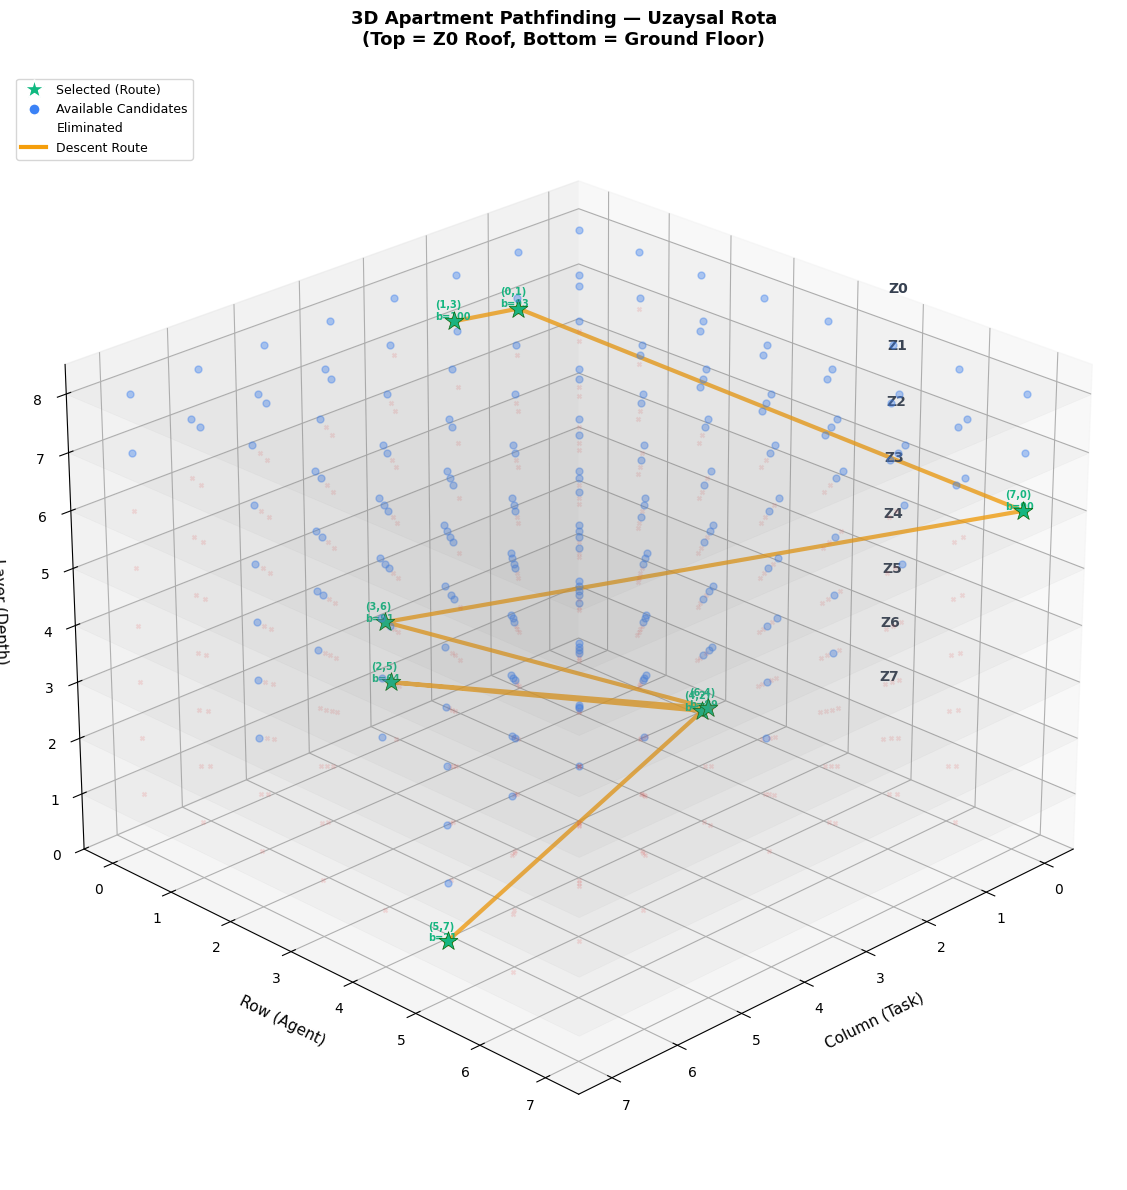


--- Layer-by-Layer Reduction ---
 Layer       Cell  Benefit    Score  Candidates  Search Space
------------------------------------------------------------
  Z0    ( 1, 3)       100    100.0          64            64
  Z1    ( 0, 1)        93     91.1          49            49
  Z2    ( 7, 0)        90     90.0          35            36
  Z3    ( 3, 6)        91     91.0          24            25
  Z4    ( 6, 4)        89     83.4          16            16
  Z5    ( 2, 5)        64     64.0           8             9
  Z6    ( 4, 2)        60     60.0           3             4
  Z7    ( 5, 7)        21     21.0           1             1

Total cells evaluated: 200
vs brute force: 8! = 40,320


In [15]:
# --- 3D Apartment Visualization ---
if route_apt:
    visualize_apartment_3d(C_viz, route_apt, conflicts_viz, nb_viz, N_viz)
    
    # Also show the layer-by-layer reduction
    print("\n--- Layer-by-Layer Reduction ---")
    print(f"{'Layer':>6} {'Cell':>10} {'Benefit':>8} {'Score':>8} {'Candidates':>11} {'Search Space':>13}")
    print("-" * 60)
    for layer in route_apt:
        d = layer['depth']
        sel = layer['selected']
        nc = len(layer['candidates'])
        space = len(layer['avail_rows']) * len(layer['avail_cols'])
        if sel:
            print(f"  Z{d:<4} ({sel[0]:2d},{sel[1]:2d})  {sel[2]:8.0f} {sel[3]:8.1f} {nc:11d} {space:13d}")
    
    total_cells = sum(len(l['candidates']) for l in route_apt)
    print(f"\nTotal cells evaluated: {total_cells}")
    print(f"vs brute force: {N_viz}! = {math.factorial(N_viz):,}")
else:
    print("No route to visualize (solution not found)")

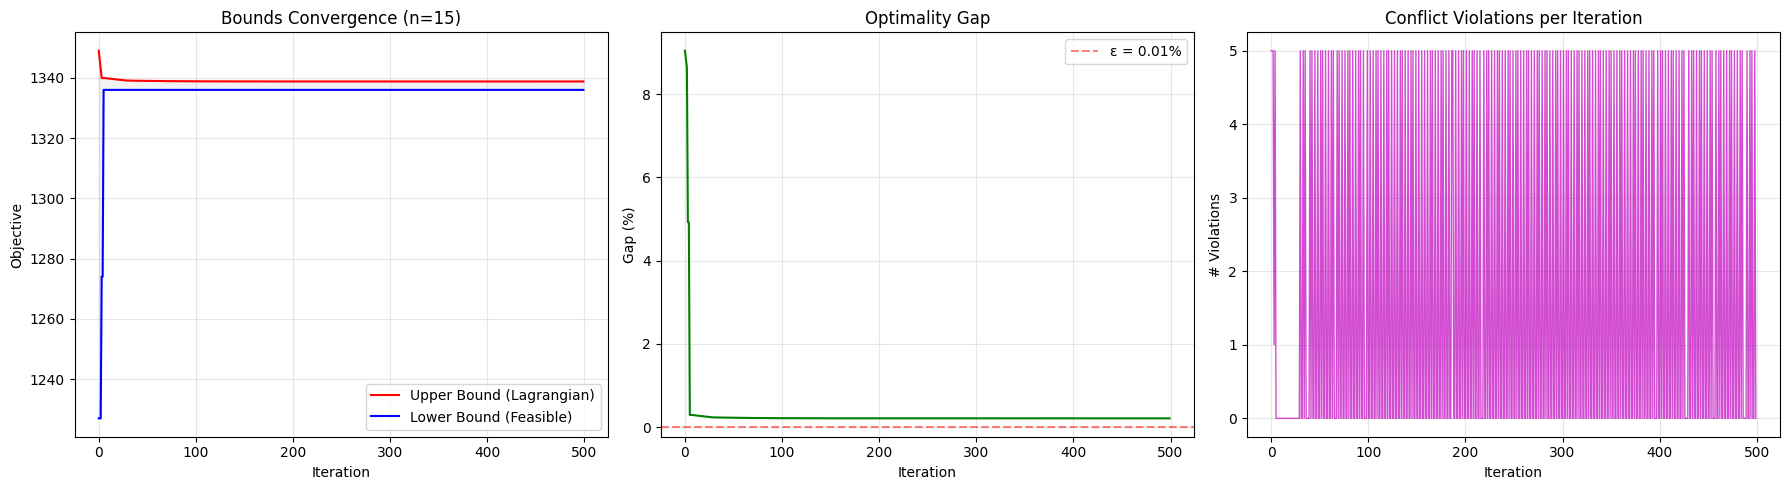


Final: UB=1338.80, LB=1336.00, Gap=0.2089%


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

h = result['history']
iters = range(len(h['UB']))

# Plot 1: Bounds convergence
axes[0].plot(iters, h['UB'], 'r-', label='Upper Bound (Lagrangian)', linewidth=1.5)
axes[0].plot(iters, h['LB'], 'b-', label='Lower Bound (Feasible)', linewidth=1.5)
axes[0].fill_between(iters, h['LB'], h['UB'], alpha=0.1, color='gray')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Objective')
axes[0].set_title(f'Bounds Convergence (n={N})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Gap
axes[1].plot(iters, h['gap'], 'g-', linewidth=1.5)
axes[1].axhline(y=0.01, color='red', linestyle='--', alpha=0.5, label='ε = 0.01%')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Gap (%)')
axes[1].set_title('Optimality Gap')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Violations
axes[2].plot(iters, h['violations'], 'm-', linewidth=1, alpha=0.7)
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('# Violations')
axes[2].set_title('Conflict Violations per Iteration')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('convergence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFinal: UB={result['UB_best']:.2f}, LB={result['LB_best']:.2f}, Gap={result['gap']:.4f}%")

---
## 7. Solution Details

In [17]:
if result['x_best'] is not None:
    x = result['x_best']
    print("Best feasible assignment:")
    print(f"  {'Agent':>6}  {'Task':>6}  {'Benefit':>8}")
    print(f"  {'-'*6}  {'-'*6}  {'-'*8}")
    total = 0
    for i in range(N):
        b = C[i, x[i]]
        total += b
        print(f"  {i:6d}  {x[i]:6d}  {b:8.0f}")
    print(f"  {'':>6}  {'TOTAL':>6}  {total:8.0f}")
    
    violations = find_violations(x, conflicts)
    print(f"\nViolations: {len(violations)}")
    print(f"Feasible: {len(violations) == 0}")
else:
    print("No feasible solution found!")

Best feasible assignment:
   Agent    Task   Benefit
  ------  ------  --------
       0      10        88
       1      13        89
       2       3        92
       3      11        90
       4       0        92
       5       5        90
       6       2        87
       7       6        88
       8      14        88
       9       7        99
      10       9        96
      11       8        86
      12       4        84
      13      12        79
      14       1        88
           TOTAL      1336

Violations: 0
Feasible: True


---
## 8. Experiment: Different Problem Sizes

In [18]:
experiments = [
    {'n': 8,  'density': 0.01, 'label': 'Small (8×8, 1%)'},
    {'n': 15, 'density': 0.02, 'label': 'Medium (15×15, 2%)'},
    {'n': 25, 'density': 0.01, 'label': 'Large (25×25, 1%)'},
    {'n': 40, 'density': 0.005, 'label': 'XL (40×40, 0.5%)'},
]

exp_results = []
for exp in experiments:
    print(f"\n{'='*60}")
    print(f"  {exp['label']}")
    print(f"{'='*60}")
    
    C_exp, conflicts_exp = generate_instance(exp['n'], 1, 100, exp['density'], seed=42)
    conflicts_exp, fz, nb = presolve(C_exp, conflicts_exp, verbose=True)
    
    r = subgradient_solve(
        C_exp, conflicts_exp, nb, fz,
        max_iter=300, alpha_init=2.0, eps=0.01, verbose=True
    )
    r['label'] = exp['label']
    exp_results.append(r)

# Summary table
print(f"\n\n{'='*75}")
print(f"{'Instance':<25} {'UB':>10} {'LB':>10} {'Gap':>8} {'Time':>8} {'Iters':>6}")
print(f"{'-'*75}")
for r in exp_results:
    print(f"{r['label']:<25} {r['UB_best']:10.1f} {r['LB_best']:10.1f} "
          f"{r['gap']:7.3f}% {r['elapsed']:7.2f}s {len(r['history']['UB']):6d}")
print(f"{'='*75}")


  Small (8×8, 1%)
Valid conflict pool: 1568 pairs
Generated conflicts: 15 (1.0% of pool)

[Aşama 0] Mantıksal İndirgeme (Preprocessing) Başladı...
  Temiz conflict sayısı: 15

[Aşama 0] Tamamlandı. 1 iterasyonda 0 hücre elendi.
=== PRESOLVE RESULTS ===
  Original conflicts:  15
  After dedup:         15
  Eliminated cells:    0 / 64
  Alive cells:         64 / 64
  Reduced conflicts:   15
  Edges in conflicts:  21 / 64
  Max conflict degree: 3
Greedy LB: 594 (feasible=True)
  k=   0  UB=    668.00  LB=    668.00  Gap=  0.00%  Viol=0  α=2.0000

*** OPTIMAL (gap < 0.01%) at iteration 0 ***

  RESULTS
  Upper Bound (UB): 668.00
  Lower Bound (LB): 668.00
  Gap:              0.0000%
  Time:             0.00s
  Iterations:       1
  Status:           OPTIMAL

  Medium (15×15, 2%)
Valid conflict pool: 22050 pairs
Generated conflicts: 441 (2.0% of pool)

[Aşama 0] Mantıksal İndirgeme (Preprocessing) Başladı...
  Temiz conflict sayısı: 441

[Aşama 0] Tamamlandı. 1 iterasyonda 0 hücre elendi.


  k=  50  UB=   2391.98  LB=   2359.00  Gap=  1.38%  Viol=1  α=1.0000
  k= 100  UB=   2391.69  LB=   2359.00  Gap=  1.37%  Viol=2  α=0.5000
  k= 150  UB=   2391.58  LB=   2359.00  Gap=  1.36%  Viol=2  α=0.1250


  k= 200  UB=   2391.54  LB=   2359.00  Gap=  1.36%  Viol=1  α=0.0625
  k= 250  UB=   2391.53  LB=   2359.00  Gap=  1.36%  Viol=2  α=0.0156

  RESULTS
  Upper Bound (UB): 2391.53
  Lower Bound (LB): 2359.00
  Gap:              1.3602%
  Time:             0.55s
  Iterations:       300
  Status:           Gap not closed

  XL (40×40, 0.5%)
Valid conflict pool: 1216800 pairs
Generated conflicts: 6084 (0.5% of pool)

[Aşama 0] Mantıksal İndirgeme (Preprocessing) Başladı...
  Temiz conflict sayısı: 6084



[Aşama 0] Tamamlandı. 1 iterasyonda 0 hücre elendi.
=== PRESOLVE RESULTS ===
  Original conflicts:  6084
  After dedup:         6084
  Eliminated cells:    0 / 1600
  Alive cells:         1600 / 1600
  Reduced conflicts:   6084
  Edges in conflicts:  1600 / 1600
  Max conflict degree: 18
Greedy LB: 3729 (feasible=False)
  k=   0  UB=   3857.00  LB=   3800.00  Gap=  1.48%  Viol=4  α=2.0000
  k=   1  UB=   3856.96  LB=   3828.00  Gap=  0.75%  Viol=2  α=2.0000
  k=   2  UB=   3856.94  LB=   3828.00  Gap=  0.75%  Viol=2  α=2.0000
  k=   3  UB=   3856.92  LB=   3828.00  Gap=  0.75%  Viol=2  α=2.0000
  k=   4  UB=   3856.90  LB=   3828.00  Gap=  0.75%  Viol=2  α=2.0000


  k=  50  UB=   3856.17  LB=   3828.00  Gap=  0.73%  Viol=2  α=1.0000


  k= 100  UB=   3855.89  LB=   3828.00  Gap=  0.72%  Viol=2  α=0.2500


  k= 150  UB=   3855.81  LB=   3828.00  Gap=  0.72%  Viol=2  α=0.1250


  k= 200  UB=   3855.78  LB=   3828.00  Gap=  0.72%  Viol=2  α=0.0312


  k= 250  UB=   3855.77  LB=   3828.00  Gap=  0.72%  Viol=2  α=0.0078



  RESULTS
  Upper Bound (UB): 3855.77
  Lower Bound (LB): 3828.00
  Gap:              0.7202%
  Time:             1.85s
  Iterations:       300
  Status:           Gap not closed


Instance                          UB         LB      Gap     Time  Iters
---------------------------------------------------------------------------
Small (8×8, 1%)                668.0      668.0   0.000%    0.00s      1
Medium (15×15, 2%)            1338.8     1336.0   0.209%    0.14s    300
Large (25×25, 1%)             2391.5     2359.0   1.360%    0.55s    300
XL (40×40, 0.5%)              3855.8     3828.0   0.720%    1.85s    300
